# 05 — Train GaitTR with CrossEntropy + Triplet Loss

এই notebook pure triplet-loss collapse problem fix করার জন্য বানানো।

Main changes:

```text
1. GaitTR backbone আগের মতো থাকবে
2. 128-D embedding থাকবে
3. classifier head add করা হয়েছে
4. loss = CrossEntropy + Triplet
5. প্রথমে CE-only warmup, তারপর CE + Triplet
6. left/right swap augmentation default OFF
7. embedding collapse diagnostics added
8. evaluation-compatible checkpoint save হবে
```

Default project path:

```text
/media/wadud/DriveUbuntu/GaitRecognition 2.0
```

Expected input:

```text
data/splits/train_LT.csv
data/poses/<pose_model_tag>/**/*.npz
```

After training, evaluation checkpoint:

```text
checkpoints/gaittr_LT_ce_triplet_last.pth
```

Use this checkpoint in `06_evaluate_gaittr_fixed_recommended.ipynb`.

In [1]:
# ============================================================
# CELL 1 — Imports, config, paths
# ============================================================

from pathlib import Path
import random
import time
import json
import gc

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader, Sampler
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt

# ----------------------------
# Reproducibility
# ----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ----------------------------
# Project paths
# ----------------------------
EXP_DIR = Path("/media/wadud/DriveUbuntu/GaitRecognition 2.0")
SPLIT_NAME = "LT"

SPLIT_DIR = EXP_DIR / "data" / "splits"
CHECKPOINT_DIR = EXP_DIR / "checkpoints"
LOG_DIR = EXP_DIR / "logs"
RESULT_DIR = EXP_DIR / "results"

for d in [CHECKPOINT_DIR, LOG_DIR, RESULT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

TRAIN_CSV = SPLIT_DIR / f"train_{SPLIT_NAME}.csv"

# ----------------------------
# Model config
# ----------------------------
SEQ_LEN = 60
NUM_JOINTS = 17
IN_CHANNELS = 10
EMBEDDING_DIM = 128

CHANNELS = (64, 64, 128, 256)
NUM_HEADS = 8
TEMPORAL_KERNEL = 9
DROPOUT = 0.1

# ----------------------------
# Training config
# ----------------------------
# Your GPU handled batch 32 easily. CE+Triplet default uses batch 64.
# If CUDA OOM happens, set P=8, K=4.
P = 16
K = 4
BATCH_SIZE = P * K

NUM_WORKERS = 2

MAX_STEPS = 30000
STEPS_PER_EPOCH = 1000

LR_MAX = 1e-3
WEIGHT_DECAY = 2e-5

MARGIN = 0.3
CE_WEIGHT = 1.0
TRIPLET_WEIGHT_MAX = 0.2

# CE-only warmup prevents embedding collapse early.
CE_ONLY_STEPS = 2000
TRIPLET_RAMP_STEPS = 3000

LABEL_SMOOTHING = 0.1

USE_AMP = True
GRAD_CLIP_NORM = 5.0

LOG_EVERY = 50
SAVE_EVERY = 1000

# ----------------------------
# Augmentation config
# ----------------------------
# Left/right swap is risky for gait + view angle, so default OFF.
AUGMENT = True
USE_LEFT_RIGHT_SWAP = False
JOINT_NOISE_STD = 0.003
GLOBAL_SHIFT_STD = 0.006

# ----------------------------
# Run switches
# ----------------------------
# Recommended: run tiny sanity first.
RUN_TINY_SANITY_TEST = False
RUN_FULL_TRAINING = True

TINY_SUBJECTS = 8
TINY_STEPS = 800

# Resume full training from full checkpoint if needed.
RESUME_FROM_FULL = None
# Example:
# RESUME_FROM_FULL = "/media/wadud/DriveUbuntu/GaitRecognition 2.0/checkpoints/gaittr_LT_ce_triplet_full_step_10000.pth"

RUN_NAME = f"gaittr_{SPLIT_NAME}_ce_triplet"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 80)
print("GaitTR CE + Triplet Training Notebook")
print("=" * 80)
print("EXP_DIR     :", EXP_DIR)
print("TRAIN_CSV   :", TRAIN_CSV)
print("RUN_NAME    :", RUN_NAME)
print("Device      :", device)
if torch.cuda.is_available():
    print("GPU         :", torch.cuda.get_device_name(0))
    print("CUDA        :", torch.version.cuda)
print("Batch config:", f"P={P}, K={K}, batch={BATCH_SIZE}")
print("=" * 80)

assert TRAIN_CSV.exists(), f"Missing {TRAIN_CSV}. Run 03_prepare_casiab_splits.ipynb first."

GaitTR CE + Triplet Training Notebook
EXP_DIR     : /media/wadud/DriveUbuntu/GaitRecognition 2.0
TRAIN_CSV   : /media/wadud/DriveUbuntu/GaitRecognition 2.0/data/splits/train_LT.csv
RUN_NAME    : gaittr_LT_ce_triplet
Device      : cuda
GPU         : NVIDIA GeForce RTX 3060 Laptop GPU
CUDA        : 12.8
Batch config: P=16, K=4, batch=64


In [2]:
# ============================================================
# CELL 2 — Read train split safely
# ============================================================

df_train_full = pd.read_csv(
    TRAIN_CSV,
    dtype={
        "pose_path": str,
        "subject": str,
        "condition": str,
        "seq": str,
        "view": str,
    }
)

required_cols = {"pose_path", "subject", "condition", "seq", "view"}
missing_cols = required_cols - set(df_train_full.columns)
assert not missing_cols, f"Missing columns in train CSV: {missing_cols}"

missing_paths = [p for p in df_train_full["pose_path"].tolist() if not Path(p).exists()]

print("Train samples :", len(df_train_full))
print("Train subjects:", df_train_full["subject"].nunique())
print("Missing paths :", len(missing_paths))

if missing_paths:
    print("First missing path:", missing_paths[0])
    raise FileNotFoundError("Some pose files are missing.")

display(df_train_full.head())
display(df_train_full.groupby(["condition", "seq"]).size().reset_index(name="count"))

Train samples : 8140
Train subjects: 74
Missing paths : 0


,pose_path,subject,condition,seq,view
0,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,bg,01,000
1,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,bg,01,018
2,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,bg,01,036
3,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,bg,01,054
4,/media/wadud/DriveUbuntu/GaitRecognition 2.0/d...,001,bg,01,072


,condition,seq,count
0,bg,01,814
1,bg,02,814
2,cl,01,814
3,cl,02,814
4,nm,01,814
5,nm,02,814
6,nm,03,814
7,nm,04,814
8,nm,05,814
9,nm,06,814


In [3]:
# ============================================================
# CELL 3 — Feature builder and safe augmentation
# ============================================================

COCO_PARENTS = np.array([
    0,   # nose
    0,   # left_eye
    0,   # right_eye
    1,   # left_ear
    2,   # right_ear
    0,   # left_shoulder
    0,   # right_shoulder
    5,   # left_elbow
    6,   # right_elbow
    7,   # left_wrist
    8,   # right_wrist
    5,   # left_hip
    6,   # right_hip
    11,  # left_knee
    12,  # right_knee
    13,  # left_ankle
    14,  # right_ankle
], dtype=np.int64)

LEFT_RIGHT_PAIRS = [
    (1, 2), (3, 4),
    (5, 6), (7, 8), (9, 10),
    (11, 12), (13, 14), (15, 16),
]

def crop_or_pad_sequence(X, seq_len=60, random_crop=True):
    T = X.shape[0]

    if T == seq_len:
        return X

    if T > seq_len:
        if random_crop:
            start = np.random.randint(0, T - seq_len + 1)
        else:
            start = max(0, (T - seq_len) // 2)
        return X[start:start + seq_len]

    pad_len = seq_len - T
    pad = np.repeat(X[-1:], pad_len, axis=0)
    return np.concatenate([X, pad], axis=0)

def swap_left_right(X):
    X = X.copy()
    for l, r in LEFT_RIGHT_PAIRS:
        X[:, [l, r], :] = X[:, [r, l], :]
    return X

def augment_skeleton(X):
    if USE_LEFT_RIGHT_SWAP and np.random.rand() < 0.5:
        X = swap_left_right(X)

    if JOINT_NOISE_STD > 0:
        X = X + np.random.normal(0.0, JOINT_NOISE_STD, size=X.shape).astype(np.float32)

    if GLOBAL_SHIFT_STD > 0:
        X = X + np.random.normal(0.0, GLOBAL_SHIFT_STD, size=(1, 1, 2)).astype(np.float32)

    return X.astype(np.float32)

def build_gaittr_features(X):
    X = X.astype(np.float32)

    assert X.ndim == 3, f"Expected (T,17,2), got {X.shape}"
    assert X.shape[1] == 17, f"Expected 17 joints, got {X.shape[1]}"
    assert X.shape[2] == 2, f"Expected 2D coordinates, got {X.shape[2]}"

    joint = X.copy()

    nose = X[:, 0:1, :]
    joint_rel = X - nose

    v1 = np.zeros_like(X)
    v1[:-1] = X[1:] - X[:-1]

    v2 = np.zeros_like(X)
    v2[:-2] = X[2:] - X[:-2]

    bone = X - X[:, COCO_PARENTS, :]

    feat = np.concatenate([joint, joint_rel, v1, v2, bone], axis=-1)
    feat = feat.transpose(2, 0, 1).astype(np.float32)

    return feat

# Sanity check
sample_path = df_train_full.iloc[0]["pose_path"]
data = np.load(sample_path)
X = data["keypoints_norm_filled"].astype(np.float32)
X60 = crop_or_pad_sequence(X, SEQ_LEN, random_crop=False)
feat = build_gaittr_features(X60)

print("Skeleton shape:", X.shape)
print("Feature shape :", feat.shape)
assert feat.shape == (10, 60, 17)
print("[OK] Feature builder")

Skeleton shape: (99, 17, 2)
Feature shape : (10, 60, 17)
[OK] Feature builder


In [4]:
# ============================================================
# CELL 4 — Dataset and PK batch sampler
# ============================================================

class CASIABGaitTRDataset(Dataset):
    def __init__(self, df, label_map, seq_len=60, train=True, augment=True):
        self.df = df.reset_index(drop=True)
        self.label_map = label_map
        self.seq_len = seq_len
        self.train = train
        self.augment = augment

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        data = np.load(row["pose_path"])
        X = data["keypoints_norm_filled"].astype(np.float32)

        X = crop_or_pad_sequence(
            X,
            seq_len=self.seq_len,
            random_crop=self.train
        )

        if self.train and self.augment:
            X = augment_skeleton(X)

        feat = build_gaittr_features(X)
        label = self.label_map[str(row["subject"])]

        return {
            "x": torch.from_numpy(feat),
            "label": torch.tensor(label, dtype=torch.long),
            "subject": str(row["subject"]),
            "condition": str(row["condition"]),
            "seq": str(row["seq"]),
            "view": str(row["view"]),
            "pose_path": str(row["pose_path"]),
        }

class PKBatchSampler(Sampler):
    def __init__(self, labels, p=16, k=4, steps_per_epoch=1000):
        self.labels = np.asarray(labels)
        self.p = int(p)
        self.k = int(k)
        self.steps_per_epoch = int(steps_per_epoch)

        self.label_to_indices = {}
        for idx, label in enumerate(self.labels):
            self.label_to_indices.setdefault(int(label), []).append(idx)

        self.unique_labels = sorted(self.label_to_indices.keys())

        if len(self.unique_labels) < self.p:
            raise ValueError(f"Not enough identities: have {len(self.unique_labels)}, need p={self.p}")

    def __iter__(self):
        for _ in range(self.steps_per_epoch):
            selected_labels = random.sample(self.unique_labels, self.p)

            batch_indices = []
            for label in selected_labels:
                indices = self.label_to_indices[label]
                if len(indices) >= self.k:
                    chosen = random.sample(indices, self.k)
                else:
                    chosen = random.choices(indices, k=self.k)
                batch_indices.extend(chosen)

            yield batch_indices

    def __len__(self):
        return self.steps_per_epoch

def make_label_map(df):
    subjects = sorted([str(s) for s in df["subject"].unique()])
    return {s: i for i, s in enumerate(subjects)}

def make_train_loader(df_train, p=P, k=K, steps_per_epoch=STEPS_PER_EPOCH, augment=True):
    label_map = make_label_map(df_train)

    dataset = CASIABGaitTRDataset(
        df=df_train,
        label_map=label_map,
        seq_len=SEQ_LEN,
        train=True,
        augment=augment,
    )

    labels = [label_map[str(s)] for s in df_train["subject"].tolist()]

    sampler = PKBatchSampler(
        labels=labels,
        p=p,
        k=k,
        steps_per_epoch=steps_per_epoch,
    )

    loader = DataLoader(
        dataset,
        batch_sampler=sampler,
        num_workers=NUM_WORKERS,
        pin_memory=(device.type == "cuda"),
        persistent_workers=(NUM_WORKERS > 0),
    )

    return loader, label_map

# DataLoader sanity check
loader_check, label_map_check = make_train_loader(
    df_train_full,
    p=min(P, df_train_full["subject"].nunique()),
    k=K,
    steps_per_epoch=5,
    augment=AUGMENT,
)

batch = next(iter(loader_check))

print("Batch x shape:", batch["x"].shape)
print("Batch y shape:", batch["label"].shape)
print("Unique IDs    :", torch.unique(batch["label"]).numel())

assert batch["x"].shape[1:] == (10, 60, 17)
print("[OK] Dataset and sampler")

Batch x shape: torch.Size([64, 10, 60, 17])
Batch y shape: torch.Size([64])
Unique IDs    : 16
[OK] Dataset and sampler


In [5]:
# ============================================================
# CELL 5 — GaitTR backbone + CE classifier
# ============================================================

class TCN(nn.Module):
    def __init__(self, in_channels, out_channels, temporal_kernel=9, dropout=0.1):
        super().__init__()
        pad = temporal_kernel // 2

        self.net = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=(temporal_kernel, 1),
                padding=(pad, 0),
                bias=False
            ),
            nn.Dropout(dropout),
            nn.Mish(),
            nn.BatchNorm2d(out_channels),
        )

    def forward(self, x):
        return self.net(x)

class SpatialTransformer(nn.Module):
    def __init__(self, channels, num_heads=8, dropout=0.1):
        super().__init__()

        assert channels % num_heads == 0

        self.norm = nn.LayerNorm(channels)
        self.attn = nn.MultiheadAttention(
            embed_dim=channels,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True,
        )
        self.proj = nn.Linear(channels, channels)
        self.act = nn.Mish()
        self.bn = nn.BatchNorm2d(channels)

    def forward(self, x):
        B, C, T, V = x.shape

        tokens = x.permute(0, 2, 3, 1).contiguous()
        tokens = tokens.view(B * T, V, C)

        tokens = self.norm(tokens)
        out, _ = self.attn(tokens, tokens, tokens, need_weights=False)
        out = self.proj(out)

        out = out.view(B, T, V, C)
        out = out.permute(0, 3, 1, 2).contiguous()

        out = self.act(out)
        out = self.bn(out)

        return out

class TCNSTBlock(nn.Module):
    def __init__(self, in_channels, out_channels, num_heads=8, temporal_kernel=9, dropout=0.1):
        super().__init__()

        self.tcn = TCN(in_channels, out_channels, temporal_kernel, dropout)
        self.st = SpatialTransformer(out_channels, num_heads, dropout)

        if in_channels == out_channels:
            self.residual = nn.Identity()
        else:
            self.residual = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False),
                nn.Mish(),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x):
        return self.st(self.tcn(x)) + self.residual(x)

class GaitTRCETriplet(nn.Module):
    def __init__(
        self,
        num_classes,
        in_channels=10,
        embedding_dim=128,
        channels=(64, 64, 128, 256),
        num_heads=8,
        temporal_kernel=9,
        dropout=0.1,
    ):
        super().__init__()

        self.num_classes = int(num_classes)
        self.embedding_dim = int(embedding_dim)

        self.data_bn = nn.BatchNorm2d(in_channels)

        blocks = []
        prev_channels = in_channels
        for out_channels in channels:
            blocks.append(
                TCNSTBlock(
                    in_channels=prev_channels,
                    out_channels=out_channels,
                    num_heads=num_heads,
                    temporal_kernel=temporal_kernel,
                    dropout=dropout,
                )
            )
            prev_channels = out_channels

        self.blocks = nn.Sequential(*blocks)
        self.fc = nn.Linear(channels[-1], embedding_dim, bias=False)

        # Classifier uses raw embedding, not L2-normalized embedding.
        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, x, return_logits=True):
        x = self.data_bn(x)
        x = self.blocks(x)
        x = x.mean(dim=(2, 3))

        raw_emb = self.fc(x)
        emb = F.normalize(raw_emb, p=2, dim=1)

        if return_logits:
            logits = self.classifier(raw_emb)
            return emb, logits

        return emb

class BatchHardTripletLoss(nn.Module):
    def __init__(self, margin=0.3):
        super().__init__()
        self.margin = margin

    def forward(self, embeddings, labels, return_stats=False):
        dist = torch.cdist(embeddings, embeddings, p=2)

        labels = labels.view(-1, 1)
        same = labels.eq(labels.t())
        diff = ~same

        eye = torch.eye(labels.size(0), device=labels.device, dtype=torch.bool)
        same = same & ~eye

        hardest_pos = dist.masked_fill(~same, -1e9).max(dim=1)[0]
        hardest_neg = dist.masked_fill(~diff, 1e9).min(dim=1)[0]

        loss_all = F.relu(hardest_pos - hardest_neg + self.margin)
        valid = hardest_pos > -1e8

        if valid.sum() == 0:
            loss = torch.tensor(0.0, device=embeddings.device, requires_grad=True)
        else:
            loss = loss_all[valid].mean()

        if not return_stats:
            return loss

        stats = {
            "hard_pos_mean": float(hardest_pos[valid].detach().mean().cpu()) if valid.sum() > 0 else 0.0,
            "hard_neg_mean": float(hardest_neg[valid].detach().mean().cpu()) if valid.sum() > 0 else 0.0,
            "triplet_active_ratio": float((loss_all[valid] > 0).float().mean().detach().cpu()) if valid.sum() > 0 else 0.0,
        }
        return loss, stats

def make_model(num_classes):
    return GaitTRCETriplet(
        num_classes=num_classes,
        in_channels=IN_CHANNELS,
        embedding_dim=EMBEDDING_DIM,
        channels=CHANNELS,
        num_heads=NUM_HEADS,
        temporal_kernel=TEMPORAL_KERNEL,
        dropout=DROPOUT,
    ).to(device)

# Model sanity check
num_classes_check = len(label_map_check)
model_check = make_model(num_classes_check)
dummy = torch.randn(2, 10, 60, 17).to(device)
with torch.no_grad():
    emb, logits = model_check(dummy)
print("Embedding:", emb.shape)
print("Logits   :", logits.shape)
assert emb.shape == (2, EMBEDDING_DIM)
assert logits.shape == (2, num_classes_check)

del model_check, dummy, emb, logits
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("[OK] Model")

Embedding: torch.Size([2, 128])
Logits   : torch.Size([2, 74])
[OK] Model


In [6]:
# ============================================================
# CELL 6 — Loss weights, optimizer, checkpoint utilities
# ============================================================

def current_triplet_weight(step):
    if step < CE_ONLY_STEPS:
        return 0.0

    ramp_step = step - CE_ONLY_STEPS
    if ramp_step >= TRIPLET_RAMP_STEPS:
        return TRIPLET_WEIGHT_MAX

    return TRIPLET_WEIGHT_MAX * (ramp_step / max(TRIPLET_RAMP_STEPS, 1))

def get_amp_scaler():
    if device.type != "cuda" or not USE_AMP:
        try:
            return torch.amp.GradScaler("cuda", enabled=False)
        except Exception:
            return torch.cuda.amp.GradScaler(enabled=False)

    try:
        return torch.amp.GradScaler("cuda", enabled=True)
    except Exception:
        return torch.cuda.amp.GradScaler(enabled=True)

def autocast_context():
    if device.type != "cuda" or not USE_AMP:
        try:
            return torch.amp.autocast("cuda", enabled=False)
        except Exception:
            return torch.cuda.amp.autocast(enabled=False)

    try:
        return torch.amp.autocast("cuda", enabled=True)
    except Exception:
        return torch.cuda.amp.autocast(enabled=True)

def make_optimizer(model):
    return torch.optim.Adam(
        model.parameters(),
        lr=LR_MAX,
        weight_decay=WEIGHT_DECAY,
    )

def make_scheduler(optimizer, total_steps):
    return torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=LR_MAX,
        total_steps=total_steps,
        pct_start=0.3,
        div_factor=100.0,
        final_div_factor=100000.0,
    )

def make_config(run_name, max_steps, p, k, num_classes):
    return {
        "run_name": run_name,
        "split_name": SPLIT_NAME,
        "seq_len": SEQ_LEN,
        "in_channels": IN_CHANNELS,
        "embedding_dim": EMBEDDING_DIM,
        "channels": list(CHANNELS),
        "num_heads": NUM_HEADS,
        "temporal_kernel": TEMPORAL_KERNEL,
        "dropout": DROPOUT,
        "num_classes": int(num_classes),
        "p": int(p),
        "k": int(k),
        "batch_size": int(p * k),
        "max_steps": int(max_steps),
        "lr_max": LR_MAX,
        "weight_decay": WEIGHT_DECAY,
        "margin": MARGIN,
        "ce_weight": CE_WEIGHT,
        "triplet_weight_max": TRIPLET_WEIGHT_MAX,
        "ce_only_steps": CE_ONLY_STEPS,
        "triplet_ramp_steps": TRIPLET_RAMP_STEPS,
        "label_smoothing": LABEL_SMOOTHING,
        "augment": AUGMENT,
        "use_left_right_swap": USE_LEFT_RIGHT_SWAP,
        "joint_noise_std": JOINT_NOISE_STD,
        "global_shift_std": GLOBAL_SHIFT_STD,
        "seed": SEED,
    }

def get_eval_compatible_state_dict(model):
    # Remove classifier so existing evaluation notebook can load backbone only.
    state = model.state_dict()
    return {k: v for k, v in state.items() if not k.startswith("classifier.")}

def save_full_checkpoint(path, model, optimizer, scheduler, scaler, step, config, label_map):
    ckpt = {
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict() if optimizer is not None else None,
        "scheduler": scheduler.state_dict() if scheduler is not None else None,
        "scaler": scaler.state_dict() if scaler is not None else None,
        "step": int(step),
        "config": config,
        "label_map": label_map,
        "checkpoint_type": "full_ce_triplet_with_classifier",
    }
    torch.save(ckpt, path)

def save_eval_checkpoint(path, model, step, config, label_map):
    ckpt = {
        "model": get_eval_compatible_state_dict(model),
        "step": int(step),
        "config": config,
        "label_map": label_map,
        "checkpoint_type": "eval_backbone_only",
    }
    torch.save(ckpt, path)

def load_full_checkpoint(path, model, optimizer=None, scheduler=None, scaler=None):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model"], strict=True)

    if optimizer is not None and ckpt.get("optimizer") is not None:
        optimizer.load_state_dict(ckpt["optimizer"])

    if scheduler is not None and ckpt.get("scheduler") is not None:
        scheduler.load_state_dict(ckpt["scheduler"])

    if scaler is not None and ckpt.get("scaler") is not None:
        scaler.load_state_dict(ckpt["scaler"])

    return ckpt

In [7]:
# ============================================================
# CELL 7 — Diagnostics
# ============================================================

def batch_embedding_stats(emb):
    with torch.no_grad():
        norms = torch.norm(emb, p=2, dim=1)
        out = {
            "emb_norm_mean": float(norms.mean().detach().cpu()),
            "emb_norm_min": float(norms.min().detach().cpu()),
            "emb_norm_max": float(norms.max().detach().cpu()),
        }

        if emb.shape[0] >= 2:
            dist = torch.cdist(emb.detach(), emb.detach(), p=2)
            mask = ~torch.eye(emb.shape[0], dtype=torch.bool, device=emb.device)
            out["pairwise_mean"] = float(dist[mask].mean().detach().cpu())
            out["pairwise_min"] = float(dist[mask].min().detach().cpu())
            out["pairwise_max"] = float(dist[mask].max().detach().cpu())
        else:
            out["pairwise_mean"] = 0.0
            out["pairwise_min"] = 0.0
            out["pairwise_max"] = 0.0

        return out

In [8]:
# ============================================================
# CELL 8 — Training function
# ============================================================

def run_training(df_train, run_name, max_steps, p, k, steps_per_epoch, resume_from_full=None):
    train_loader, label_map = make_train_loader(
        df_train,
        p=p,
        k=k,
        steps_per_epoch=steps_per_epoch,
        augment=AUGMENT,
    )

    num_classes = len(label_map)

    model = make_model(num_classes=num_classes)
    ce_loss_fn = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)
    triplet_loss_fn = BatchHardTripletLoss(margin=MARGIN)

    optimizer = make_optimizer(model)
    scheduler = make_scheduler(optimizer, total_steps=max_steps)
    scaler = get_amp_scaler()

    config = make_config(run_name, max_steps, p, k, num_classes)

    start_step = 0

    if resume_from_full is not None:
        resume_from_full = Path(resume_from_full)
        assert resume_from_full.exists(), f"Resume checkpoint not found: {resume_from_full}"
        ckpt = load_full_checkpoint(resume_from_full, model, optimizer, scheduler, scaler)
        start_step = int(ckpt.get("step", 0))
        print(f"[RESUME] Loaded {resume_from_full}, start_step={start_step}")

    logs = []

    best_loss = float("inf")
    best_acc = -1.0

    full_last_path = CHECKPOINT_DIR / f"{run_name}_full_last.pth"
    eval_last_path = CHECKPOINT_DIR / f"{run_name}_last.pth"

    full_best_loss_path = CHECKPOINT_DIR / f"{run_name}_full_best_loss.pth"
    eval_best_loss_path = CHECKPOINT_DIR / f"{run_name}_best_loss.pth"

    full_best_acc_path = CHECKPOINT_DIR / f"{run_name}_full_best_train_acc.pth"
    eval_best_acc_path = CHECKPOINT_DIR / f"{run_name}_best_train_acc.pth"

    model.train()
    step = start_step
    start_time = time.time()

    pbar = tqdm(total=max_steps, initial=start_step, desc=run_name)

    while step < max_steps:
        for batch in train_loader:
            x = batch["x"].float().to(device, non_blocking=True)
            y = batch["label"].long().to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)

            tri_w = current_triplet_weight(step)

            with autocast_context():
                emb, logits = model(x, return_logits=True)

                ce = ce_loss_fn(logits, y)
                triplet, tri_stats = triplet_loss_fn(emb, y, return_stats=True)

                loss = CE_WEIGHT * ce + tri_w * triplet

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)

            if GRAD_CLIP_NORM is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=GRAD_CLIP_NORM)

            scaler.step(optimizer)
            scaler.update()
            scheduler.step()

            with torch.no_grad():
                pred = torch.argmax(logits, dim=1)
                train_acc = (pred == y).float().mean().item()

            loss_value = float(loss.detach().cpu())
            ce_value = float(ce.detach().cpu())
            tri_value = float(triplet.detach().cpu())
            lr = float(scheduler.get_last_lr()[0])
            elapsed = time.time() - start_time

            if step % LOG_EVERY == 0:
                emb_stats = batch_embedding_stats(emb)

                log_row = {
                    "step": step,
                    "loss": loss_value,
                    "ce_loss": ce_value,
                    "triplet_loss": tri_value,
                    "triplet_weight": tri_w,
                    "train_batch_acc": train_acc,
                    "lr": lr,
                    "elapsed_sec": elapsed,
                    "batch_size": p * k,
                    "p": p,
                    "k": k,
                    **tri_stats,
                    **emb_stats,
                }
                logs.append(log_row)

                pbar.set_postfix({
                    "loss": f"{loss_value:.4f}",
                    "ce": f"{ce_value:.3f}",
                    "tri": f"{tri_value:.3f}",
                    "acc": f"{train_acc:.2f}",
                    "pw": f"{emb_stats['pairwise_mean']:.3f}",
                })

                if loss_value < best_loss:
                    best_loss = loss_value
                    save_full_checkpoint(full_best_loss_path, model, optimizer, scheduler, scaler, step, config, label_map)
                    save_eval_checkpoint(eval_best_loss_path, model, step, config, label_map)

                if train_acc > best_acc:
                    best_acc = train_acc
                    save_full_checkpoint(full_best_acc_path, model, optimizer, scheduler, scaler, step, config, label_map)
                    save_eval_checkpoint(eval_best_acc_path, model, step, config, label_map)

            if step > 0 and step % SAVE_EVERY == 0:
                full_step_path = CHECKPOINT_DIR / f"{run_name}_full_step_{step}.pth"
                eval_step_path = CHECKPOINT_DIR / f"{run_name}_step_{step}.pth"

                save_full_checkpoint(full_step_path, model, optimizer, scheduler, scaler, step, config, label_map)
                save_eval_checkpoint(eval_step_path, model, step, config, label_map)

            step += 1
            pbar.update(1)

            if step >= max_steps:
                break

    pbar.close()

    save_full_checkpoint(full_last_path, model, optimizer, scheduler, scaler, step, config, label_map)
    save_eval_checkpoint(eval_last_path, model, step, config, label_map)

    df_log = pd.DataFrame(logs)

    log_csv = LOG_DIR / f"{run_name}_train_log.csv"
    config_json = LOG_DIR / f"{run_name}_config.json"

    df_log.to_csv(log_csv, index=False)

    with open(config_json, "w") as f:
        json.dump(config, f, indent=2)

    if len(df_log) > 0:
        plt.figure(figsize=(10, 4))
        plt.plot(df_log["step"], df_log["loss"], label="total")
        plt.plot(df_log["step"], df_log["ce_loss"], label="ce")
        plt.plot(df_log["step"], df_log["triplet_loss"], label="triplet")
        plt.xlabel("Step")
        plt.ylabel("Loss")
        plt.title(run_name)
        plt.grid(True, alpha=0.3)
        plt.legend()
        loss_plot = LOG_DIR / f"{run_name}_loss_curve.png"
        plt.tight_layout()
        plt.savefig(loss_plot, dpi=150)
        plt.show()

        plt.figure(figsize=(10, 4))
        plt.plot(df_log["step"], df_log["train_batch_acc"], label="batch CE acc")
        plt.plot(df_log["step"], df_log["pairwise_mean"], label="embedding pairwise mean")
        plt.xlabel("Step")
        plt.title("Training diagnostics")
        plt.grid(True, alpha=0.3)
        plt.legend()
        diag_plot = LOG_DIR / f"{run_name}_diagnostics.png"
        plt.tight_layout()
        plt.savefig(diag_plot, dpi=150)
        plt.show()

    print("=" * 80)
    print("Training finished:", run_name)
    print("Eval-compatible last checkpoint:", eval_last_path)
    print("Full last checkpoint           :", full_last_path)
    print("Eval best loss checkpoint      :", eval_best_loss_path)
    print("Eval best train-acc checkpoint :", eval_best_acc_path)
    print("Log CSV                        :", log_csv)
    print("Config JSON                    :", config_json)
    print("=" * 80)

    return model, df_log, label_map

In [9]:
# ============================================================
# CELL 9 — Tiny sanity test
# ============================================================

if RUN_TINY_SANITY_TEST:
    tiny_subjects = sorted(df_train_full["subject"].unique())[:TINY_SUBJECTS]
    df_tiny = df_train_full[df_train_full["subject"].isin(tiny_subjects)].copy()

    tiny_p = min(P, TINY_SUBJECTS)

    print("=" * 80)
    print("Tiny CE+Triplet sanity test")
    print("=" * 80)
    print("Tiny subjects:", tiny_subjects)
    print("Tiny samples :", len(df_tiny))
    print("P, K         :", tiny_p, K)
    print("Steps        :", TINY_STEPS)
    print("=" * 80)

    tiny_model, tiny_log, tiny_label_map = run_training(
        df_train=df_tiny,
        run_name=f"{RUN_NAME}_tiny",
        max_steps=TINY_STEPS,
        p=tiny_p,
        k=K,
        steps_per_epoch=100,
        resume_from_full=None,
    )

    if len(tiny_log) > 1:
        print("First total loss:", tiny_log["loss"].iloc[0])
        print("Last total loss :", tiny_log["loss"].iloc[-1])
        print("First CE loss   :", tiny_log["ce_loss"].iloc[0])
        print("Last CE loss    :", tiny_log["ce_loss"].iloc[-1])
        print("First acc       :", tiny_log["train_batch_acc"].iloc[0])
        print("Last acc        :", tiny_log["train_batch_acc"].iloc[-1])
        print("Last pairwise   :", tiny_log["pairwise_mean"].iloc[-1])

        if tiny_log["ce_loss"].iloc[-1] < tiny_log["ce_loss"].iloc[0]:
            print("[OK] Tiny CE loss decreased.")
        else:
            print("[WARNING] Tiny CE loss did not decrease.")

else:
    print("RUN_TINY_SANITY_TEST=False")

RUN_TINY_SANITY_TEST=False


gaittr_LT_ce_triplet:   0%|          | 0/30000 [00:00<?, ?it/s]

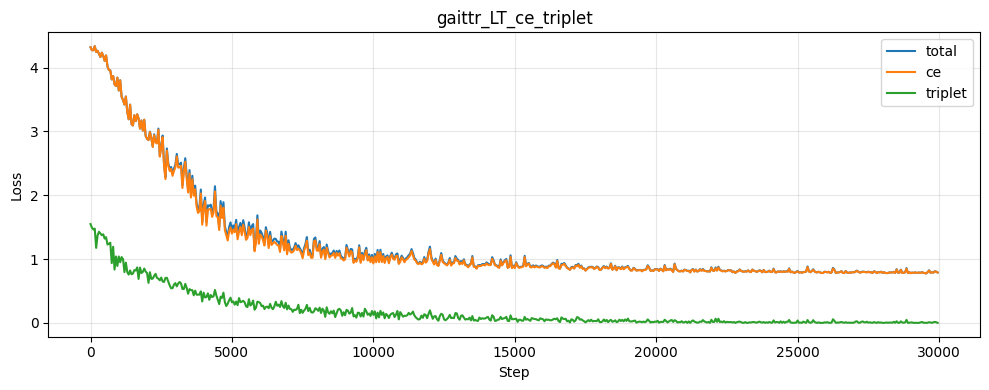

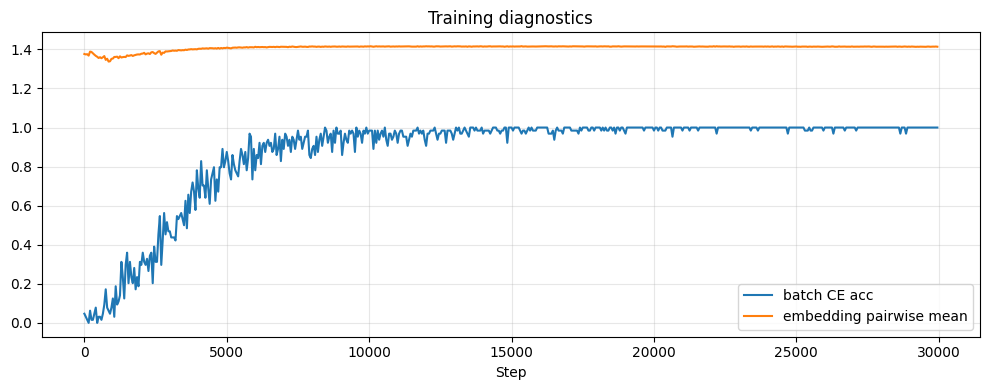

Training finished: gaittr_LT_ce_triplet
Eval-compatible last checkpoint: /media/wadud/DriveUbuntu/GaitRecognition 2.0/checkpoints/gaittr_LT_ce_triplet_last.pth
Full last checkpoint           : /media/wadud/DriveUbuntu/GaitRecognition 2.0/checkpoints/gaittr_LT_ce_triplet_full_last.pth
Eval best loss checkpoint      : /media/wadud/DriveUbuntu/GaitRecognition 2.0/checkpoints/gaittr_LT_ce_triplet_best_loss.pth
Eval best train-acc checkpoint : /media/wadud/DriveUbuntu/GaitRecognition 2.0/checkpoints/gaittr_LT_ce_triplet_best_train_acc.pth
Log CSV                        : /media/wadud/DriveUbuntu/GaitRecognition 2.0/logs/gaittr_LT_ce_triplet_train_log.csv
Config JSON                    : /media/wadud/DriveUbuntu/GaitRecognition 2.0/logs/gaittr_LT_ce_triplet_config.json


In [10]:
# ============================================================
# CELL 10 — Full CE+Triplet training
# ============================================================

if RUN_FULL_TRAINING:
    full_model, full_log, full_label_map = run_training(
        df_train=df_train_full,
        run_name=RUN_NAME,
        max_steps=MAX_STEPS,
        p=P,
        k=K,
        steps_per_epoch=STEPS_PER_EPOCH,
        resume_from_full=RESUME_FROM_FULL,
    )
else:
    print("RUN_FULL_TRAINING=False")
    print("After tiny sanity test passes, set:")
    print("RUN_TINY_SANITY_TEST = False")
    print("RUN_FULL_TRAINING = True")
    print("Then rerun this notebook/cell.")

CE+Triplet training logs:
- gaittr_LT_ce_triplet_tiny_train_log.csv
- gaittr_LT_ce_triplet_train_log.csv
Latest log: /media/wadud/DriveUbuntu/GaitRecognition 2.0/logs/gaittr_LT_ce_triplet_train_log.csv


,step,loss,ce_loss,triplet_loss,triplet_weight,train_batch_acc,lr,elapsed_sec,batch_size,p,k,hard_pos_mean,hard_neg_mean,triplet_active_ratio,emb_norm_mean,emb_norm_min,emb_norm_max,pairwise_mean,pairwise_min,pairwise_max
0,0,4.318623,4.318623,1.547863,0.0,0.046875,0.000010,0.731851,64,16,4,1.635888,0.388025,1.0,1.0,1.0,1.0,1.376469,0.137517,1.917684
1,50,4.272870,4.272870,1.491752,0.0,0.031250,0.000010,10.167399,64,16,4,1.639076,0.447323,1.0,1.0,1.0,1.0,1.374309,0.090839,1.889597
2,100,4.271782,4.271782,1.463764,0.0,0.015625,0.000010,19.617973,64,16,4,1.610719,0.446956,1.0,1.0,1.0,1.0,1.375535,0.097787,1.856904
3,150,4.335617,4.335617,1.476643,0.0,0.000000,0.000011,28.893484,64,16,4,1.595310,0.418667,1.0,1.0,1.0,1.0,1.368279,0.087811,1.838337
4,200,4.245352,4.245352,1.174998,0.0,0.062500,0.000011,37.075690,64,16,4,1.473030,0.598032,1.0,1.0,1.0,1.0,1.388676,0.131720,1.894892


,step,loss,ce_loss,triplet_loss,triplet_weight,train_batch_acc,lr,elapsed_sec,batch_size,p,k,hard_pos_mean,hard_neg_mean,triplet_active_ratio,emb_norm_mean,emb_norm_min,emb_norm_max,pairwise_mean,pairwise_min,pairwise_max
595,29750,0.793958,0.793945,0.000065,0.2,1.0,3.441762e-07,5112.606236,64,16,4,0.769896,1.287868,0.015625,1.0,1.0,1.0,1.414127,0.459010,1.643044
596,29800,0.789112,0.786919,0.010961,0.2,1.0,2.194309e-07,5121.143377,64,16,4,0.794469,1.292560,0.109375,1.0,1.0,1.0,1.414300,0.431791,1.631440
597,29850,0.809759,0.806753,0.015033,0.2,1.0,1.226482e-07,5129.699823,64,16,4,0.815374,1.274715,0.187500,1.0,1.0,1.0,1.414082,0.440974,1.670065
598,29900,0.802481,0.800494,0.009935,0.2,1.0,5.383355e-08,5138.684186,64,16,4,0.823039,1.271761,0.109375,1.0,1.0,1.0,1.414709,0.426187,1.634671
599,29950,0.789586,0.789552,0.000166,0.2,1.0,1.299086e-08,5149.048361,64,16,4,0.751424,1.293573,0.015625,1.0,1.0,1.0,1.413742,0.443311,1.638079


First total loss: 4.318623065948486
Last total loss : 0.7895856499671936
Min total loss  : 0.7759749293327332
First CE loss: 4.318623065948486
Last CE loss : 0.7895523905754089
First batch acc: 0.046875
Last batch acc : 1.0
First pairwise: 1.3764692544937134
Last pairwise : 1.4137417078018188


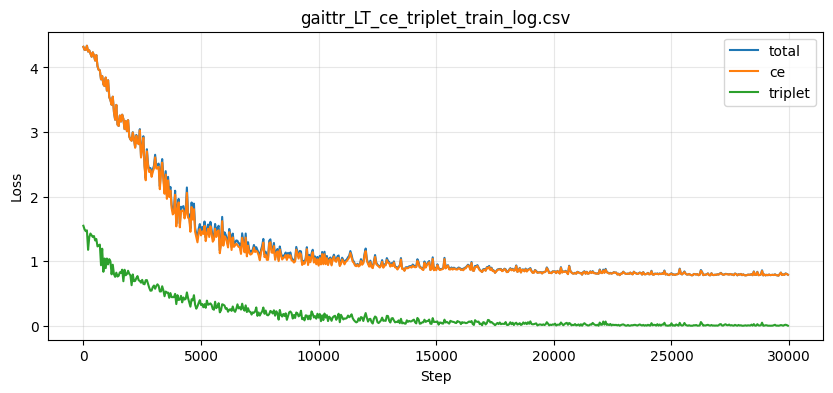

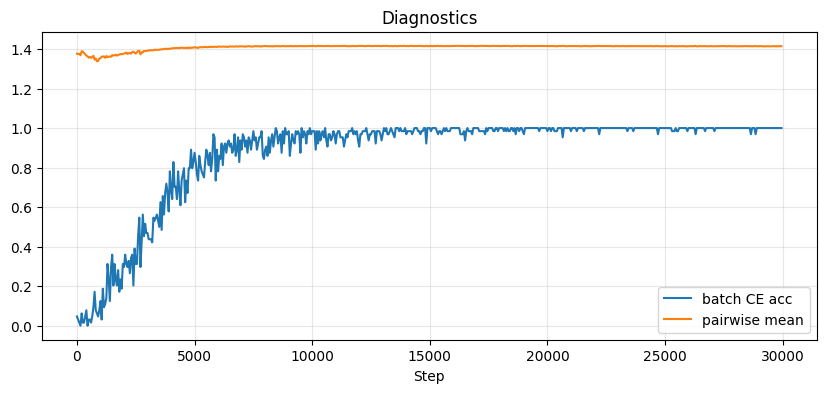

In [11]:
# ============================================================
# CELL 11 — Inspect latest CE+Triplet log
# ============================================================

log_files = sorted(LOG_DIR.glob(f"{RUN_NAME}*_train_log.csv"))

print("CE+Triplet training logs:")
for p in log_files:
    print("-", p.name)

if log_files:
    latest_log = log_files[-1]
    df_log_latest = pd.read_csv(latest_log)

    print("Latest log:", latest_log)
    display(df_log_latest.head())
    display(df_log_latest.tail())

    if len(df_log_latest) > 0:
        print("First total loss:", df_log_latest["loss"].iloc[0])
        print("Last total loss :", df_log_latest["loss"].iloc[-1])
        print("Min total loss  :", df_log_latest["loss"].min())

        print("First CE loss:", df_log_latest["ce_loss"].iloc[0])
        print("Last CE loss :", df_log_latest["ce_loss"].iloc[-1])

        print("First batch acc:", df_log_latest["train_batch_acc"].iloc[0])
        print("Last batch acc :", df_log_latest["train_batch_acc"].iloc[-1])

        print("First pairwise:", df_log_latest["pairwise_mean"].iloc[0])
        print("Last pairwise :", df_log_latest["pairwise_mean"].iloc[-1])

        plt.figure(figsize=(10, 4))
        plt.plot(df_log_latest["step"], df_log_latest["loss"], label="total")
        plt.plot(df_log_latest["step"], df_log_latest["ce_loss"], label="ce")
        plt.plot(df_log_latest["step"], df_log_latest["triplet_loss"], label="triplet")
        plt.xlabel("Step")
        plt.ylabel("Loss")
        plt.title(latest_log.name)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

        plt.figure(figsize=(10, 4))
        plt.plot(df_log_latest["step"], df_log_latest["train_batch_acc"], label="batch CE acc")
        plt.plot(df_log_latest["step"], df_log_latest["pairwise_mean"], label="pairwise mean")
        plt.xlabel("Step")
        plt.title("Diagnostics")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.show()

## After full training

Use this evaluation-compatible checkpoint in script-06:

```python
CHECKPOINT_PATH = CHECKPOINT_DIR / "gaittr_LT_ce_triplet_last.pth"
```

You can also try:

```python
CHECKPOINT_PATH = CHECKPOINT_DIR / "gaittr_LT_ce_triplet_best_loss.pth"
CHECKPOINT_PATH = CHECKPOINT_DIR / "gaittr_LT_ce_triplet_best_train_acc.pth"
```

Important signs of improvement:

```text
1. CE loss decreases
2. train_batch_acc increases
3. pairwise_mean does not collapse near zero
4. evaluation rank-1 is clearly above 2%
```